# Kalshi Market Time Series Construction
Process all markets & trades parquet files to build bid-ask spread and last price time series.

In [2]:
import pandas as pd
import numpy as np
import glob
import os
from pathlib import Path
import matplotlib.pyplot as plt
import fastparquet


REPO_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
PATH = REPO_ROOT / "data" / "kalshi"
MARKETS_DIR = PATH / "markets"
TRADES_DIR = PATH / "trades"
OUTPUT_DIR = PATH / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

market_files = sorted(MARKETS_DIR.glob("*.parquet"))
trade_files = sorted(TRADES_DIR.glob("*.parquet"))
print(f"Market files: {len(market_files)}, Trade files: {len(trade_files)}")

Market files: 769, Trade files: 7214


## Process Markets — extract bid/ask/spread/last_price per ticker over time
We process in chunks to avoid OOM, keeping only the columns we need.

In [ ]:
MARKET_COLS = ["ticker", "yes_bid", "yes_ask", "no_bid", "no_ask", "last_price", "open_time", "close_time", "status", "volume"]

chunks = []
for i, f in enumerate(market_files):
    trade_ts = pd.read_parquet(f, columns=MARKET_COLS)
    chunks.append(trade_ts)
    if (i + 1) % 100 == 0:
        print(f"  loaded {i+1}/{len(market_files)} market files")

markets = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Total market rows: {len(markets):,}")
markets.head()

  loaded 100/769 market files
  loaded 200/769 market files
  loaded 300/769 market files
  loaded 400/769 market files
  loaded 500/769 market files
  loaded 600/769 market files
  loaded 700/769 market files
Total market rows: 7,682,445


,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0


In [3]:
# Compute spreads
markets["yes_spread"] = markets["yes_ask"] - markets["yes_bid"]
markets["no_spread"] = markets["no_ask"] - markets["no_bid"]

# Parse times
markets["open_time"] = pd.to_datetime(markets["open_time"], utc=True)
markets["close_time"] = pd.to_datetime(markets["close_time"], utc=True)

markets.head()

,ticker,yes_bid,yes_ask,no_bid,no_ask,last_price,open_time,close_time,status,volume,yes_spread,no_spread
0,KXMVESPORTSMULTIGAMEEXTENDED-S2025791D973FCDE-...,0,0,100,100,0,2025-11-23 18:51:48.622007+00:00,2025-12-07 23:00:00+00:00,active,0,0,0
1,KXMVESPORTSMULTIGAMEEXTENDED-S202541FEC413CA1-...,0,0,100,100,0,2025-11-23 18:51:48.177164+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
2,KXMVESPORTSMULTIGAMEEXTENDED-S2025AF0C3DAAC7F-...,0,0,100,100,0,2025-11-23 18:51:47.066584+00:00,2025-12-08 01:20:00+00:00,active,0,0,0
3,KXMVESPORTSMULTIGAMEEXTENDED-S202559827ED1152-...,0,0,100,100,0,2025-11-23 18:51:46.970317+00:00,2025-12-07 18:00:00+00:00,active,0,0,0
4,KXMVESPORTSMULTIGAMEEXTENDED-S20252F848F1C785-...,0,0,100,100,0,2025-11-23 18:51:46.963903+00:00,2025-12-09 01:15:00+00:00,active,0,0,0


In [4]:
# Save full processed markets table
markets.to_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"), index=False)
print("Saved all_markets.parquet")

Saved all_markets.parquet


## Process Trades — last price time series from actual trade executions

In [5]:
TRADE_COLS = ["ticker", "yes_price", "no_price", "count", "taker_side", "created_time"]

# Trades are ~72M rows — process in batches and write intermediate parquets
BATCH = 500
batch_paths = []

for batch_start in range(0, len(trade_files), BATCH):
    batch_end = min(batch_start + BATCH, len(trade_files))
    chunks = []
    for f in trade_files[batch_start:batch_end]:
        chunks.append(pd.read_parquet(f, columns=TRADE_COLS))
    batch_df = pd.concat(chunks, ignore_index=True)
    batch_df["created_time"] = pd.to_datetime(batch_df["created_time"], utc=True)
    out = os.path.join(OUTPUT_DIR, f"trades_batch_{batch_start}.parquet")
    batch_df.to_parquet(out, index=False)
    batch_paths.append(out)
    print(f"  batch {batch_start}-{batch_end}: {len(batch_df):,} trades")
    del chunks, batch_df

print(f"Wrote {len(batch_paths)} trade batches")

  batch 0-500: 5,000,000 trades
  batch 500-1000: 5,000,000 trades
  batch 1000-1500: 5,000,000 trades
  batch 1500-2000: 5,000,000 trades
  batch 2000-2500: 5,000,000 trades
  batch 2500-3000: 5,000,000 trades
  batch 3000-3500: 5,000,000 trades
  batch 3500-4000: 5,000,000 trades
  batch 4000-4500: 5,000,000 trades
  batch 4500-5000: 5,000,000 trades
  batch 5000-5500: 5,000,000 trades
  batch 5500-6000: 5,000,000 trades
  batch 6000-6500: 5,000,000 trades
  batch 6500-7000: 4,994,741 trades
  batch 7000-7214: 2,140,000 trades
Wrote 15 trade batches


In [6]:
# Combine all trade batches
trades = pd.concat([pd.read_parquet(p) for p in batch_paths], ignore_index=True)
trades.sort_values("created_time", inplace=True)
trades.reset_index(drop=True, inplace=True)
print(f"Total trade rows: {len(trades):,}")
trades.head()

Total trade rows: 72,134,741


,ticker,yes_price,no_price,count,taker_side,created_time
0,HOME-21JUN-T750,76,24,5,yes,2021-06-30 20:09:14.185137+00:00
1,HOME-21JUN-T750,76,24,10,yes,2021-07-01 14:53:12.675773+00:00
2,CPI-21JUN-T0.6,17,83,100,yes,2021-07-01 14:53:38.613666+00:00
3,GDP-21JUN30-T6.0,81,19,20,yes,2021-07-01 14:54:00.422415+00:00
4,TRDDEFCN-21MAY-T30,34,66,100,yes,2021-07-01 14:54:11.235167+00:00


In [7]:
trades.to_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"), index=False)
print("Saved all_trades.parquet")

# Clean up batch files
for p in batch_paths:
    os.remove(p)

Saved all_trades.parquet


## Build per-ticker time series
For each ticker, merge the snapshot-level bid/ask from markets with the trade-level last prices.

In [ ]:
TRADE_COLS = ["ticker", "yes_price", "no_price", "count", "taker_side", "created_time"]

ts_chunks = []

for i, f in enumerate(trade_files):
    trade_ts = pd.read_parquet(f, columns=TRADE_COLS)
    trade_ts["created_time"] = pd.to_datetime(trade_ts["created_time"], utc=True)
    trade_ts.set_index("created_time", inplace=True)
    
    # Resample per ticker within this chunk
    g = trade_ts.groupby("ticker")["yes_price"].resample("1min").agg(["last", "mean", "count"]).dropna(subset=["last"])
    ts_chunks.append(g.reset_index())
    
    if (i + 1) % 500 == 0:
        # Flush to disk periodically to free memory
        part = pd.concat(ts_chunks, ignore_index=True)
        part.to_parquet(os.path.join(OUTPUT_DIR, f"ts_part_{i}.parquet"), index=False)
        ts_chunks = []
        print(f"  flushed at file {i+1}/{len(trade_files)}")

# Final flush
if ts_chunks:
    part = pd.concat(ts_chunks, ignore_index=True)
    part.to_parquet(os.path.join(OUTPUT_DIR, "ts_part_final.parquet"), index=False)
    del ts_chunks, part

print("Done chunked resample. Now merging parts...")

# Reload parts and re-aggregate (since a ticker may span multiple files)
parts = [pd.read_parquet(f) for f in glob.glob(os.path.join(OUTPUT_DIR, "ts_part_*.parquet"))]
trade_ts = pd.concat(parts, ignore_index=True)
del parts

# Re-aggregate overlapping (ticker, minute) rows across chunks
trade_ts = (
    trade_ts.groupby(["ticker", "created_time"])
    .agg(last_yes_price=("last", "last"), vwap_yes=("mean", "mean"), n_trades=("count", "sum"))
    .reset_index()
)

trade_ts.to_parquet(os.path.join(OUTPUT_DIR, "trade_timeseries_1min.parquet"), index=False)
print(f"Trade time series rows: {len(trade_ts):,}")

# Cleanup temp parts
for f in glob.glob(os.path.join(OUTPUT_DIR, "ts_part_*.parquet")):
    os.remove(f)

KeyboardInterrupt: 

In [ ]:
trade_ts.to_parquet(os.path.join(OUTPUT_DIR, "trade_timeseries_1min.parquet"), index=False)
print("Saved trade_timeseries_1min.parquet")

Saved trade_timeseries_1min.parquet


## Quick summary stats & sanity checks

In [40]:
# Load processed data
markets = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_markets.parquet"))
trades = pd.read_parquet(os.path.join(OUTPUT_DIR, "all_trades.parquet"))
trade_ts = pd.read_parquet(os.path.join(OUTPUT_DIR, "trade_timeseries_1min.parquet"))

# what is created time type?
print(type(trades["created_time"].iloc[0]))


<class 'pandas._libs.tslibs.timestamps.Timestamp'>


In [41]:
print("\n=== Trades ===")
print(f"Unique tickers traded: {trades['ticker'].nunique():,}")
print(f"Date range: {trades['created_time'].min()} -> {trades['created_time'].max()}")
print(f"Total number of trades: {len(trades):,}")
print(f"Yes price stats:")
print(trades["yes_price"].describe())


=== Trades ===
Unique tickers traded: 586,025
Date range: 2021-06-30 20:09:14.185137+00:00 -> 2025-11-25 22:00:15.194245+00:00
Total number of trades: 72,134,741
Yes price stats:
count    7.213474e+07
mean     4.400762e+01
std      2.779086e+01
min      0.000000e+00
25%      2.000000e+01
50%      4.300000e+01
75%      6.500000e+01
max      9.900000e+01
Name: yes_price, dtype: float64


Most traded ticker: PRES-2024-DJT


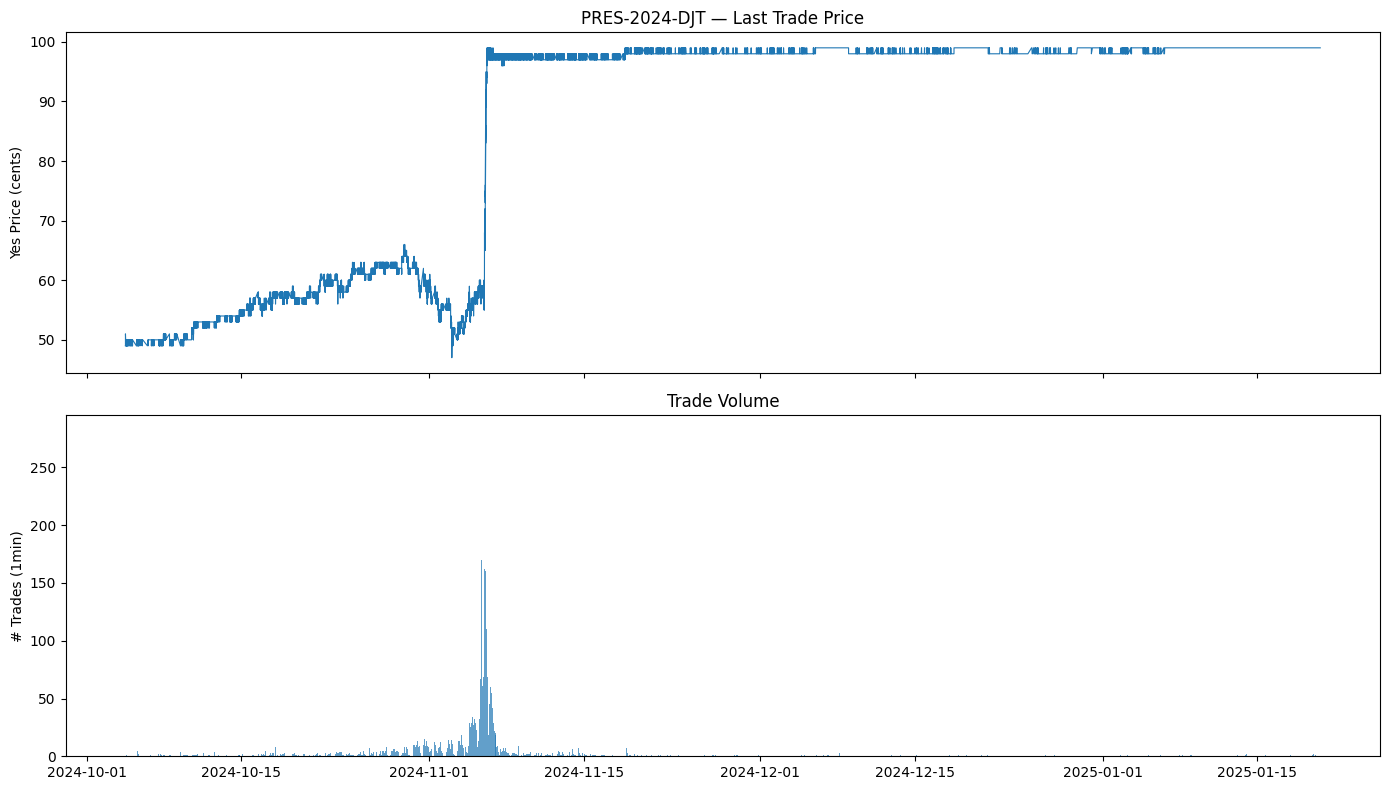

In [42]:


# Pick ticker with most trades
top_ticker = trades.groupby("ticker").size().idxmax()
print(f"Most traded ticker: {top_ticker}")

ts = trade_ts[trade_ts["ticker"] == top_ticker].set_index("created_time")
mkt = markets[markets["ticker"] == top_ticker].iloc[0]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(ts.index, ts["last_yes_price"], lw=0.8)
axes[0].set_ylabel("Yes Price (cents)")
axes[0].set_title(f"{top_ticker} — Last Trade Price")

axes[1].bar(ts.index, ts["n_trades"], width=0.0007, alpha=0.7)
axes[1].set_ylabel("# Trades (1min)")
axes[1].set_title("Trade Volume")

plt.tight_layout()
plt.show()



### Liquidity metrics

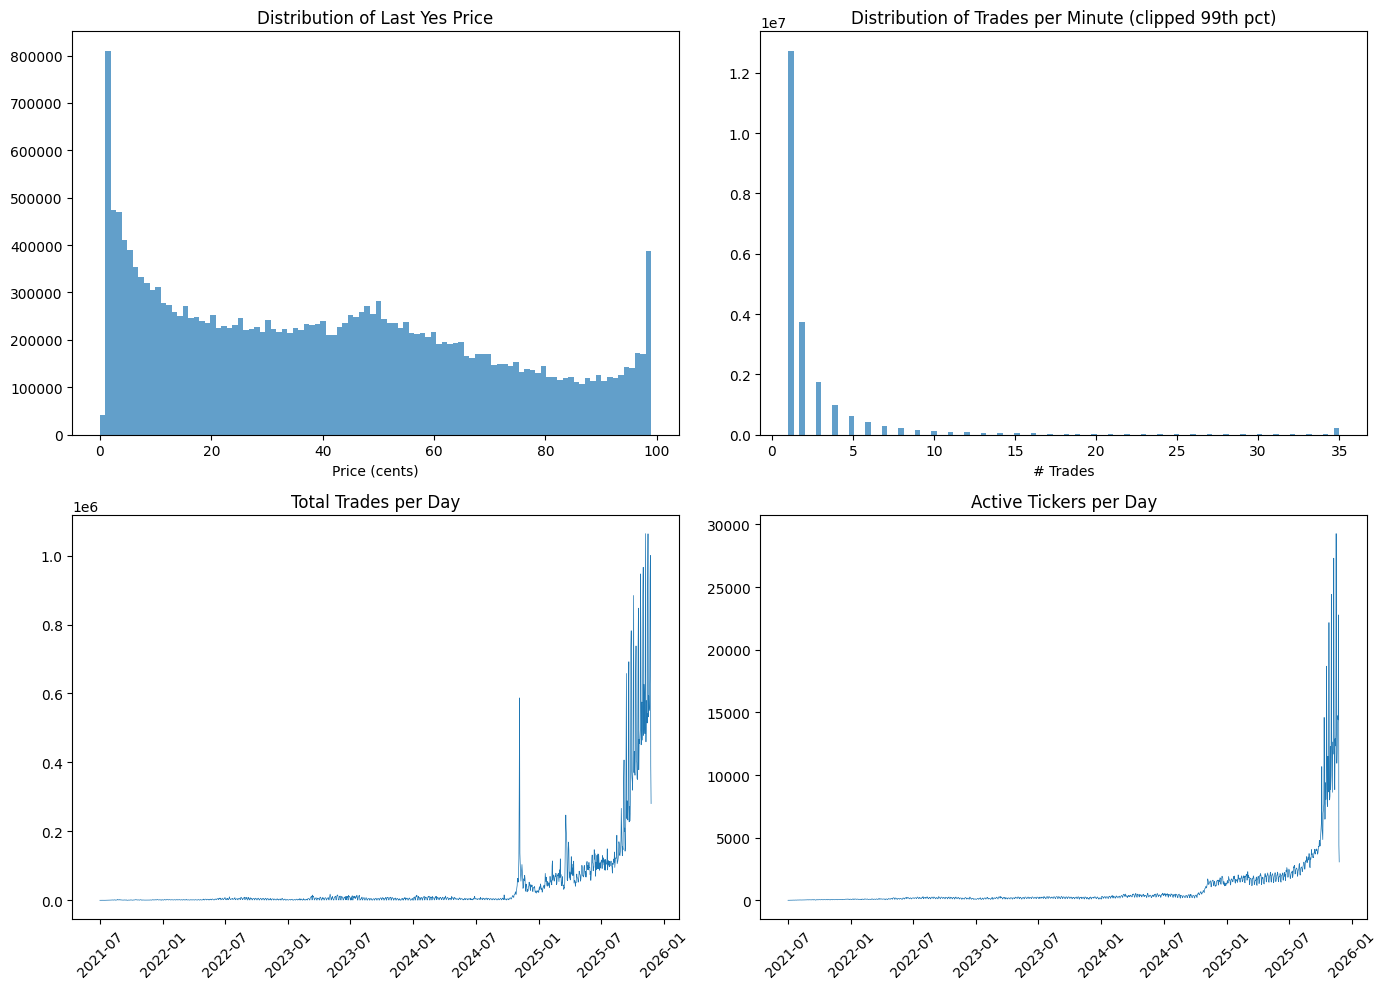

In [43]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trade_ts["last_yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trade_ts["n_trades"].clip(upper=trade_ts["n_trades"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Trades per Minute (clipped 99th pct)")
axes[0, 1].set_xlabel("# Trades")

# Trades per day
daily = trade_ts.groupby(trade_ts["created_time"].dt.date)["n_trades"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Total Trades per Day")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trade_ts.groupby(trade_ts["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Filtering poor contracts
### Do not want poor data from illiquid contracts 
- At first wanted to filter by number of a contract
    - However this introduces lookahead bias
- Decided to cut by timestamp, since Kalshi was not heavily used before a certain point


In [44]:
# Find the first day with > 200k trades
daily_trades = trade_ts.groupby(trade_ts["created_time"].dt.date)["n_trades"].sum()
first_200k = daily_trades[daily_trades > 200000].index[0]
print(f"First day with > 200k trades: {first_200k}")
original_rows = len(trade_ts)
# Fix: convert date -> UTC-aware Timestamp for comparison
first_200k_ts = pd.Timestamp(first_200k, tz='UTC')

# Remove all tickers whose final trade is before this date
last_trade = trade_ts.groupby("ticker")["created_time"].max()
keep_tickers = last_trade[last_trade >= first_200k_ts].index
trade_ts = trade_ts[trade_ts["ticker"].isin(keep_tickers)].reset_index(drop=True)
print(f"Kept {len(keep_tickers):,} tickers, dropped {(last_trade < first_200k_ts).sum():,}")
print(f"Rows after filtering: {original_rows:,} -> {len(trade_ts):,} rows")


# Remove all trades before this date as well
original_rows = len(trade_ts)
trade_ts = trade_ts[trade_ts["created_time"] >= first_200k_ts].reset_index(drop=True)
print(f"Rows after removing early trades: {original_rows:,} -> {len(trade_ts):,} rows")

First day with > 200k trades: 2024-11-05
Kept 532,925 tickers, dropped 53,100
Rows after filtering: 21,919,678 -> 19,999,952 rows
Rows after removing early trades: 19,999,952 -> 19,581,198 rows


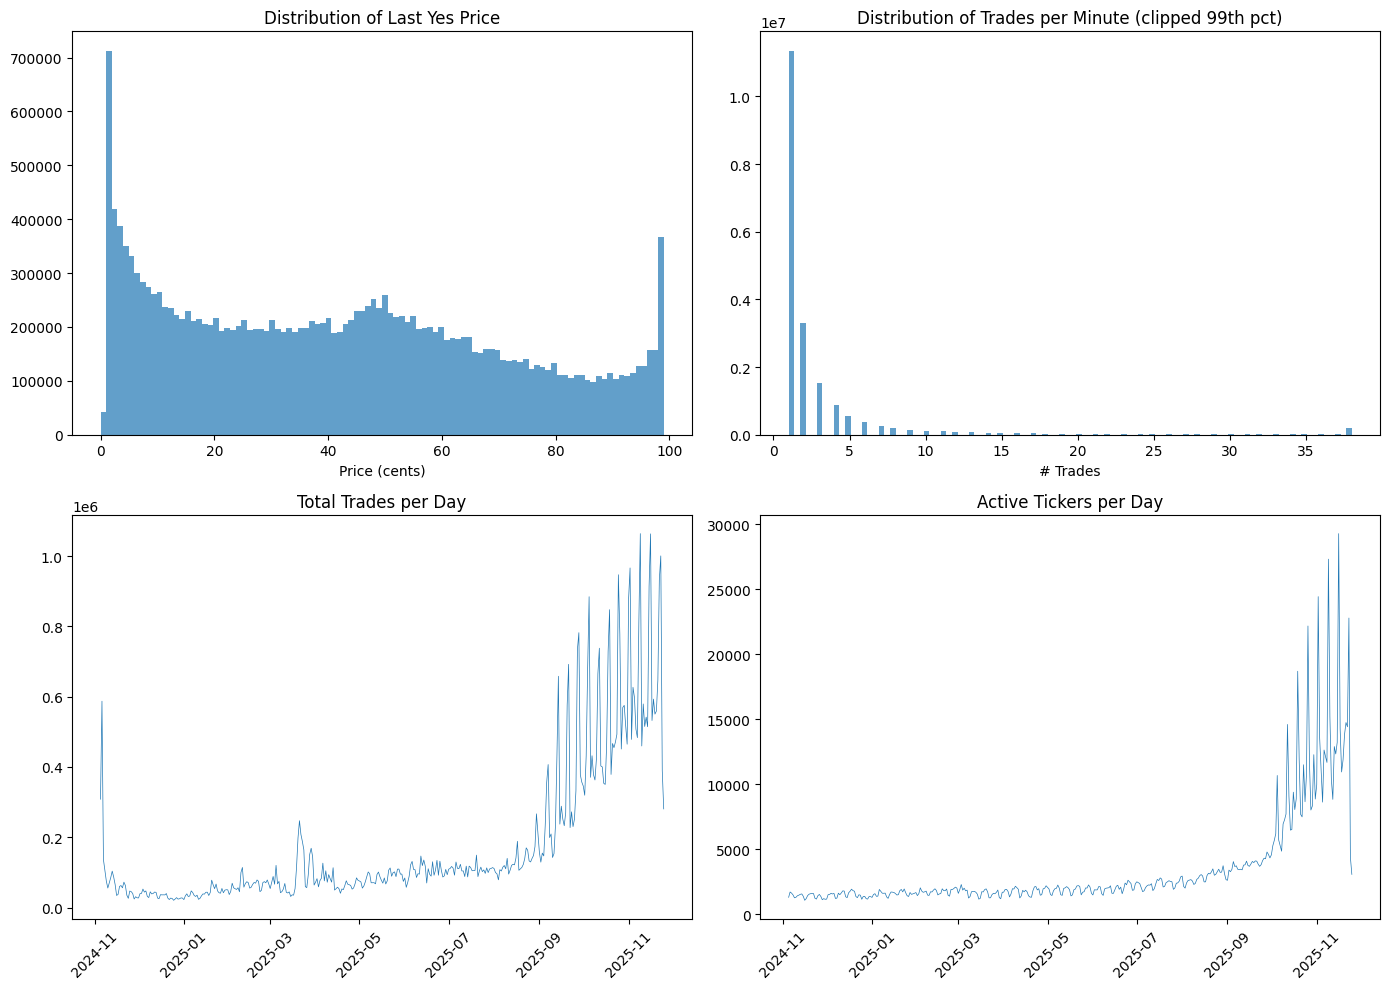

In [45]:
# Distribution of last_yes_price
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(trade_ts["last_yes_price"], bins=100, edgecolor="none", alpha=0.7)
axes[0, 0].set_title("Distribution of Last Yes Price")
axes[0, 0].set_xlabel("Price (cents)")

axes[0, 1].hist(trade_ts["n_trades"].clip(upper=trade_ts["n_trades"].quantile(0.99)), bins=100, edgecolor="none", alpha=0.7)
axes[0, 1].set_title("Distribution of Trades per Minute (clipped 99th pct)")
axes[0, 1].set_xlabel("# Trades")

# Trades per day
daily = trade_ts.groupby(trade_ts["created_time"].dt.date)["n_trades"].sum()
axes[1, 0].plot(daily.index, daily.values, lw=0.5)
axes[1, 0].set_title("Total Trades per Day")
axes[1, 0].tick_params(axis="x", rotation=45)

# Active tickers per day
active = trade_ts.groupby(trade_ts["created_time"].dt.date)["ticker"].nunique()
axes[1, 1].plot(active.index, active.values, lw=0.5)
axes[1, 1].set_title("Active Tickers per Day")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Additional features

In [48]:
# Get the final last_yes_price per ticker, then classify
def classify_last_price(price):
    if 0 <= price <= 5:
        return 0
    elif 95 <= price <= 100:
        return 1
    else:
        return float('nan')
    
    
last_price_per_ticker = (
    trade_ts.sort_values('created_time')
            .groupby('ticker')['last_yes_price']
            .last()
            .map(classify_last_price)
            .rename('outcome')
)

trade_ts = trade_ts.merge(last_price_per_ticker, on='ticker', how='left')

In [49]:
# what percentage of tickers have each classification
outcome_counts = last_price_per_ticker.value_counts(dropna=False)
print("Outcome distribution:")
print(outcome_counts)
print("\nPercentage distribution:")
print(outcome_counts / len(last_price_per_ticker) * 100)


Outcome distribution:
outcome
0.0    269150
NaN    183700
1.0     80075
Name: count, dtype: int64

Percentage distribution:
outcome
0.0    50.504292
NaN    34.470141
1.0    15.025566
Name: count, dtype: float64


# Exploratory Data Analysis

Top 20 tickers by total trades:
ticker
PRES-2024-DJT                  182934
KXMLB-25-LAD                   149605
PRES-2024-KH                   140595
KXNBA-25-IND                   103818
KXNFLGAME-25OCT02SFLA-SF        91859
KXNFLGAME-25SEP28GBDAL-DAL      87729
KXMLB-25-TOR                    87246
KXNFLGAME-25OCT06KCJAC-JAC      81846
KXNFLGAME-25OCT02SFLA-LA        78836
KXNFLGAME-25OCT06KCJAC-KC       78116
KXNFLGAME-25OCT20TBDET-TB       75915
KXMARMAD-25-FL                  72592
KXNFLGAME-25SEP28GBDAL-GB       72016
KXNBA-25-OKC                    69502
KXNFLGAME-25OCT13BUFATL-BUF     69474
KXNFLGAME-25SEP08MINCHI-MIN     68981
KXNFLGAME-25OCT12DETKC-DET      68547
KXNFLGAME-25SEP22DETBAL-DET     67852
KXNFLGAME-25NOV03ARIDAL-DAL     65488
KXNFLGAME-25OCT09PHINYG-PHI     64699
Name: n_trades, dtype: int64


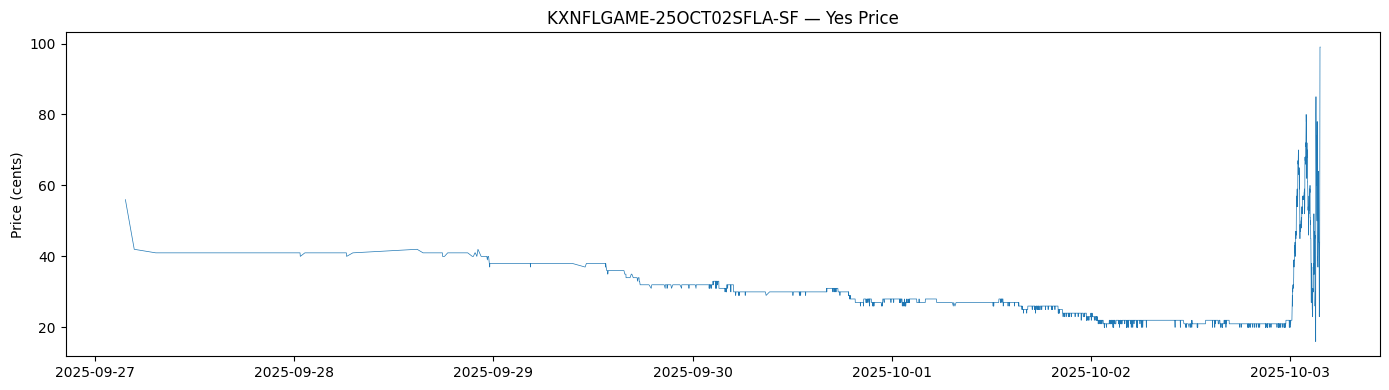

In [46]:
# Top 20 most traded tickers
top20 = trade_ts.groupby("ticker")["n_trades"].sum().nlargest(20)
print("Top 20 tickers by total trades:")
print(top20)

# Plot
top_ticker = top20.index[4]
ts = trade_ts[trade_ts["ticker"] == top_ticker].set_index("created_time").sort_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(ts.index, ts["last_yes_price"], lw=0.5)
ax.set_title(f"{top_ticker} — Yes Price")
ax.set_ylabel("Price (cents)")
plt.tight_layout()
plt.show()

In [ ]:
vol_per_ticker = trade_ts.groupby("ticker")["approx_volume"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7)
axes[0].set_title("Approx Volume per Ticker (vwap × n_trades)")
axes[0].set_xlabel("Volume (cents)")

axes[1].hist(vol_per_ticker, bins=100, edgecolor="none", alpha=0.7, log=True)
axes[1].set_title("Approx Volume per Ticker (log scale)")
axes[1].set_xlabel("Volume (cents)")

plt.tight_layout()
plt.show()

print(vol_per_ticker.describe())



KeyError: 'Column not found: approx_volume'

## Lets look at things in terms of returns

In [31]:
trade_ts['created_time'] = pd.to_datetime(trade_ts['created_time'], utc=True)
trade_ts = trade_ts.sort_values(['ticker', 'created_time'])

output_path = Path('returns_5min.parquet')
chunks = []
FLUSH_EVERY = 50  # write to disk every N tickers

for i, (ticker, grp) in enumerate(trade_ts.groupby('ticker')):
    grp = grp.set_index('created_time')[['last_yes_price', 'vwap_yes', 'n_trades']]
    
    df_5min = grp.resample('5min').agg({
        'last_yes_price': 'last',
        'vwap_yes':       'mean',
        'n_trades':       'sum'
    })
    
    df_5min['had_trade']            = df_5min['n_trades'] > 0
    df_5min['last_yes_price_ffill'] = df_5min['last_yes_price'].ffill()
    df_5min = df_5min.loc[df_5min['last_yes_price_ffill'].notna()]  # drop pre-first-trade rows
    
    df_5min['simple_return'] = df_5min['last_yes_price_ffill'].pct_change()
    df_5min['log_return']    = np.log(
        df_5min['last_yes_price_ffill'] / df_5min['last_yes_price_ffill'].shift(1)
    )
    df_5min.loc[~df_5min['had_trade'], ['simple_return', 'log_return']] = np.nan
    df_5min['ticker'] = ticker
    
    chunks.append(df_5min.reset_index(names='timestamp'))
    del df_5min  # free immediately
    
    # Flush to disk periodically
    if (i + 1) % FLUSH_EVERY == 0:
        pd.concat(chunks, ignore_index=True).to_parquet(
            output_path, 
            engine='fastparquet',
            append=output_path.exists()
        )
        chunks.clear()
        print(f"Flushed {i+1} tickers...")

# Final flush
if chunks:
    pd.concat(chunks, ignore_index=True).to_parquet(
        output_path,
        engine='fastparquet', 
        append=output_path.exists()
    )

print("Done. Loading result...")
returns_5min = pd.read_parquet(output_path)
display(returns_5min.head(20))
print(returns_5min.shape)

Flushed 50 tickers...
Flushed 100 tickers...
Flushed 150 tickers...
Flushed 200 tickers...
Flushed 250 tickers...
Flushed 300 tickers...
Flushed 350 tickers...
Flushed 400 tickers...
Flushed 450 tickers...
Flushed 500 tickers...
Flushed 550 tickers...
Flushed 600 tickers...
Flushed 650 tickers...
Flushed 700 tickers...
Flushed 750 tickers...
Flushed 800 tickers...
Flushed 850 tickers...
Flushed 900 tickers...
Flushed 950 tickers...
Flushed 1000 tickers...
Flushed 1050 tickers...
Flushed 1100 tickers...
Flushed 1150 tickers...
Flushed 1200 tickers...
Flushed 1250 tickers...
Flushed 1300 tickers...
Flushed 1350 tickers...
Flushed 1400 tickers...
Flushed 1450 tickers...
Flushed 1500 tickers...
Flushed 1550 tickers...
Flushed 1600 tickers...
Flushed 1650 tickers...
Flushed 1700 tickers...
Flushed 1750 tickers...
Flushed 1800 tickers...
Flushed 1850 tickers...
Flushed 1900 tickers...
Flushed 1950 tickers...
Flushed 2000 tickers...
Flushed 2050 tickers...
Flushed 2100 tickers...
Flushed 2150

c:\Users\ablan\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


Flushed 133650 tickers...
Flushed 133700 tickers...
Flushed 133750 tickers...
Flushed 133800 tickers...
Flushed 133850 tickers...
Flushed 133900 tickers...
Flushed 133950 tickers...
Flushed 134000 tickers...
Flushed 134050 tickers...
Flushed 134100 tickers...
Flushed 134150 tickers...
Flushed 134200 tickers...
Flushed 134250 tickers...
Flushed 134300 tickers...
Flushed 134350 tickers...
Flushed 134400 tickers...
Flushed 134450 tickers...
Flushed 134500 tickers...
Flushed 134550 tickers...
Flushed 134600 tickers...
Flushed 134650 tickers...
Flushed 134700 tickers...
Flushed 134750 tickers...
Flushed 134800 tickers...
Flushed 134850 tickers...
Flushed 134900 tickers...
Flushed 134950 tickers...
Flushed 135000 tickers...
Flushed 135050 tickers...
Flushed 135100 tickers...
Flushed 135150 tickers...
Flushed 135200 tickers...
Flushed 135250 tickers...
Flushed 135300 tickers...
Flushed 135350 tickers...
Flushed 135400 tickers...
Flushed 135450 tickers...
Flushed 135500 tickers...
Flushed 1355

KeyboardInterrupt: 

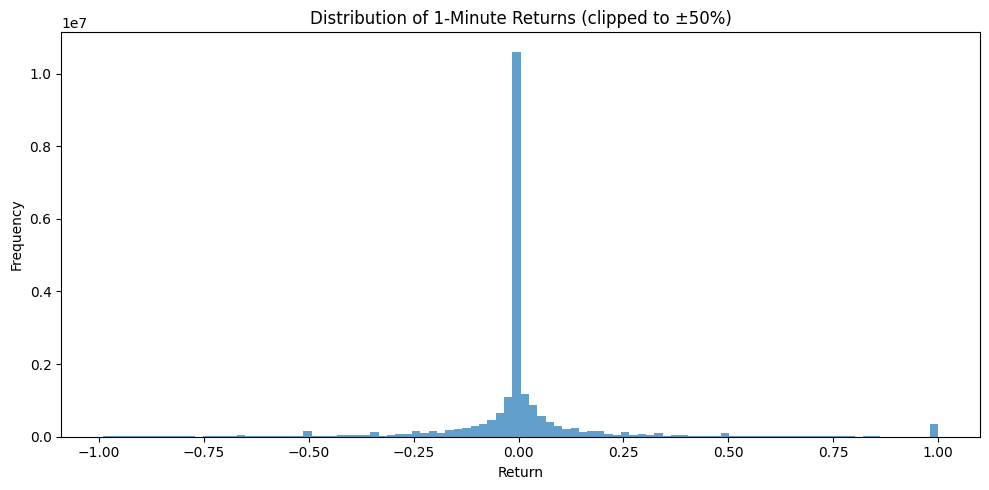

In [ ]:
# Plot histogram of returns
plt.figure(figsize=(10, 5))
plt.hist(trade_ts["returns"].dropna().clip(-1, 1), bins=100, edgecolor="none", alpha=0.7)
plt.title("Distribution of 1-Minute Returns (clipped to ±100%)")
plt.xlabel("Return")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


In [ ]:
# Describe returns
print(trade_ts["returns"].describe())

count    2.131819e+07
mean     4.467627e-02
std      1.019390e+00
min     -9.898990e-01
25%     -1.162791e-02
50%      0.000000e+00
75%      1.234568e-02
max      9.800000e+01
Name: returns, dtype: float64


All 